# Salary Prediction Model using Linear Regression

## Importing Required Libraries
We start by loading all Python libraries needed for data handling, visualization, and machine learning.


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

## Loading the Dataset
We load the Salary dataset and inspect its structure

In [26]:
df = pd.read_csv("Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [27]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


(375, 6)

In [28]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [29]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

## Handling Missing Values
We remove rows with missing data using `dropna()` to avoid model issues.


In [30]:
df = df.dropna()

In [31]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

## Exploratory Data Analysis (EDA)

We analyze:
- Age distribution  
- Salary variation across Education Levels  
- Salary differences by Gender  
- Relationship between Experience and Salary  


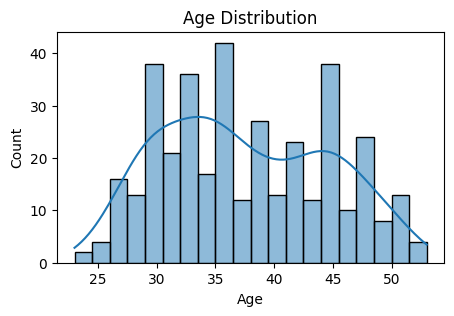

In [32]:
plt.figure(figsize=(5,3))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

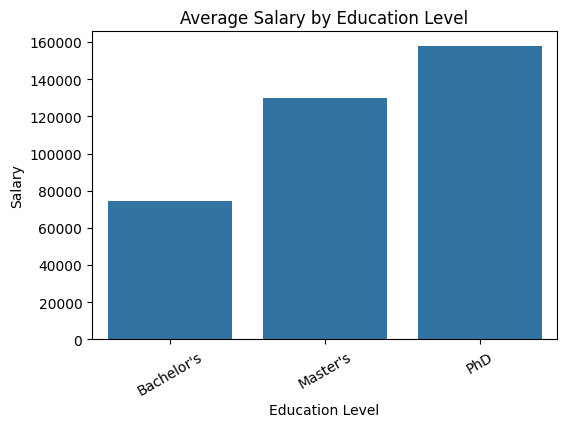

In [33]:
plt.figure(figsize=(6,4))
sns.barplot(x='Education Level', y='Salary', data=df, estimator='mean', errorbar=None)
plt.title("Average Salary by Education Level")
plt.xticks(rotation=30)
plt.show()

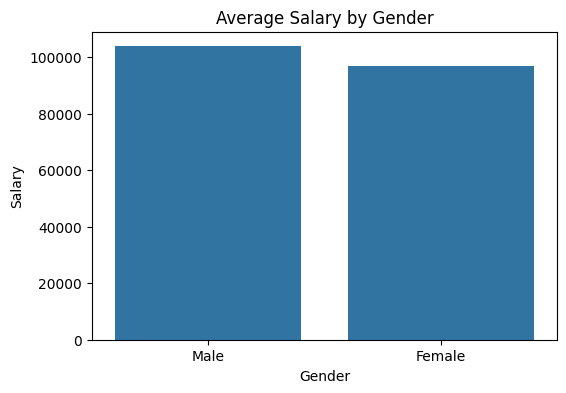

In [34]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Salary', data=df, estimator='mean', errorbar=None)
plt.title("Average Salary by Gender")
plt.show()

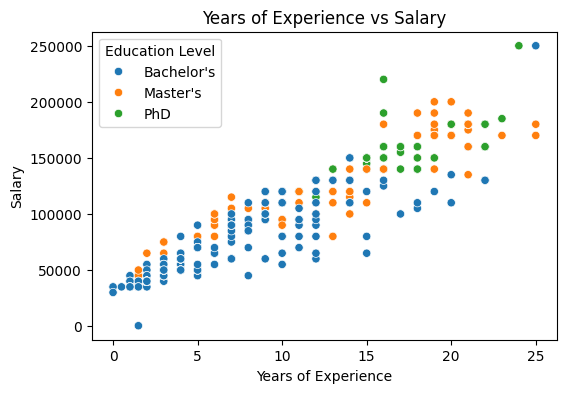

In [35]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Years of Experience', y='Salary', hue='Education Level', data=df)
plt.title("Years of Experience vs Salary")
plt.show()

## Encoding Categorical Columns
Gender, Education Level, and Job Title are categorical, so we convert them to numeric form using Label Encoding.


In [36]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_edu = LabelEncoder()
le_job = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Education Level'] = le_edu.fit_transform(df['Education Level'])
df['Job Title'] = le_job.fit_transform(df['Job Title'])
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


## Splitting Dataset
We split the data into training and testing sets (80% train, 20% test) to evaluate model performance.


In [37]:
X = df.drop('Salary', axis=1)
y = df['Salary']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Understanding Linear Regression (Theory)
## Simple Linear Regression
Formula: y = b0 + b1*x

## Multiple Linear Regression
Formula: y = b0 + b1x1 + b2x2 + ... + bn*xn


# Training Machine Learning Models

We train the following regression models:
- Linear Regression  
- Decision Tree Regressor  
- Random Forest Regressor  
- Voting Regressor (ensemble)

Each model is evaluated using:
- R² Score  
- Mean Absolute Error (MAE)


In [51]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2_lr = r2_score(y_test, y_pred)
mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
print("Linear Regression R2 Score:", r2_lr)
print("Linear Regression MAE:", mae_lr)
print("Linear Regression MSE:", mse_lr)

Linear Regression R2 Score: 0.8961138207821872
Linear Regression MAE: 10928.921486231367
Linear Regression MSE: 249075656.4272197


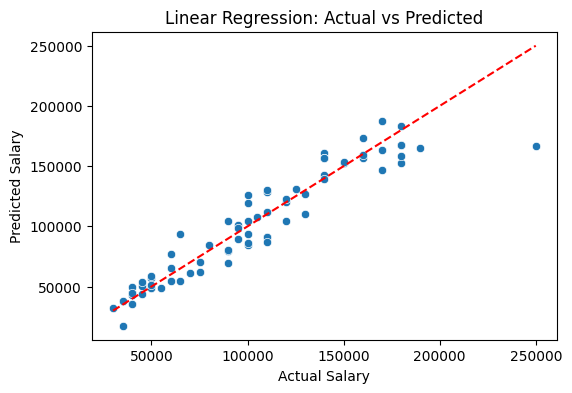

In [40]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred, )
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [41]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)
print("Random Forest R2 score:",r2_rf)
print("Random Forest MAE:", mae_rf)

Random Forest R2 score: 0.9401211962232473
Random Forest MAE: 8524.791


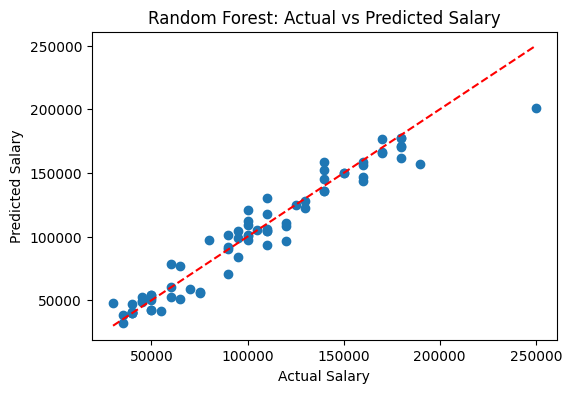

In [42]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Random Forest: Actual vs Predicted Salary")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [43]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
print("Decision Tree R2 score:", r2_dt)
print("Decision Tree MAE:", mae_dt)

Decision Tree R2 score: 0.888359755012457
Decision Tree MAE: 10466.666666666666


In [44]:
from sklearn.ensemble import VotingRegressor
voting_reg = VotingRegressor([('lr', model),('dt', dt_model),('rf', rf)])
voting_reg.fit(X_train, y_train)
y_pred_voting = voting_reg.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error
r2_voting = r2_score(y_test, y_pred_voting)
mae_voting = mean_absolute_error(y_test, y_pred_voting)

print("Voting Regressor R2 Score:", r2_voting)
print("Voting Regressor MAE:", mae_voting)

Voting Regressor R2 Score: 0.9369624572190467
Voting Regressor MAE: 9052.821070533073


## Model Performance Comparison

We compare all trained models and use a bar chart of R2 Scores to find the best-performing model.


In [45]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Voting Regressor'],
    'R2 Score': [r2_lr, r2_dt, r2_rf,r2_voting ],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_voting]
})
print(comparison)

               Model  R2 Score           MAE
0  Linear Regression  0.896114  10928.921486
1      Decision Tree  0.888360  10466.666667
2      Random Forest  0.940121   8524.791000
3   Voting Regressor  0.936962   9052.821071


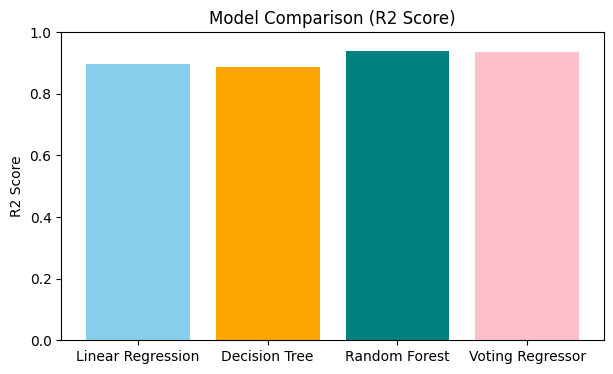

In [46]:
plt.figure(figsize=(7,4))
plt.bar(comparison['Model'], comparison['R2 Score'], color=['skyblue','orange','teal','pink'])
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.ylim(0,1)
plt.show()

## Saving the Model
We save the Linear Regression model using joblib for future predictions

In [47]:
import joblib 
joblib.dump(model, 'salary_prediction.pkl') 


['salary_prediction.pkl']

## Salary Prediction Using User Input
We create a function predict_salary() that takes input from the user, processes it, and predicts the salary using the saved Linear Regression model.

In [49]:
model = joblib.load('salary_prediction.pkl')

def predict_salary():
    print("=== Salary Prediction System ===")
    print("Linear Regression Formula:")
    print("y = b0 + b1*Age + b2*Gender + b3*Education + b4*JobTitle + b5*Experience")
    print("\nThis formula is used by the model to estimate the salary.\n")

    age = float(input("Enter Age: "))
    gender = input("Enter Gender (Male/Female): ").strip().lower()
    edu = input("Enter Education Level (Bachelor/Master/PhD): ").strip().lower()
    job_id = int(input("Enter Job Title (encoded number): "))
    exp = float(input("Enter Years of Experience: "))

    gender_val = 1 if gender == "male" else 0
    
    if edu == "bachelor":
        edu_val = 0
    elif edu == "master":
        edu_val = 1
    else:
        edu_val = 2

    user_df = pd.DataFrame({
        'Age': [age],
        'Gender': [gender_val],
        'Education Level': [edu_val],
        'Job Title': [job_id],
        'Years of Experience': [exp]
    })

    predicted_salary = model.predict(user_df)[0]
    print(f"\nPredicted Salary: ${predicted_salary:,.2f}")

predict_salary()

=== Salary Prediction System ===
Linear Regression Formula:
y = b0 + b1*Age + b2*Gender + b3*Education + b4*JobTitle + b5*Experience

This formula is used by the model to estimate the salary.



Enter Age:  35
Enter Gender (Male/Female):  Male
Enter Education Level (Bachelor/Master/PhD):  Master
Enter Job Title (encoded number):  22
Enter Years of Experience:  7



Predicted Salary: $92,771.79
